# Logistic Regression
Logistic Regression is a popular and powerful machine learning algorithm used to model the relationship between a binary target variable and one or more input variables. Despite its name, Logistic Regression is, in modern terminology, a classification algorithm rather than a regression algorithm. The name arises because the method is based on mechanisms similar to those used in Linear Regression, with the key difference being the application of a logistic (sigmoid) function to map predictions to probabilities.

In Logistic Regression, the target variable $Y$ is assumed to be binary and represents class membership. For example, the target could represent **Sex** with two constituent categories **Male** and **Female** However, the model operates on a binary representation of the target variable. By convention, we define $Y \in \{0, 1\}$ where:
 * 0 represents one class, and
 * 1 represents the other class.

For a model with a single predictor feature and a binary target variable, we can assume a training set consisting of *m* observations:

\begin{equation}
\{ (X^{1},Y^{1}),(X^{2},Y^{2}),(X^{3},Y^{3})\dots(X^{m},Y^{m})               \}
\end{equation}

where the superscript notation denotes the index of a particular training instance.

To demonstrate the form and use of the logistic function in the case of a single predictor feature, we now introduce an example based on the relationship between Type II diabetes and average daily sugar consumption.

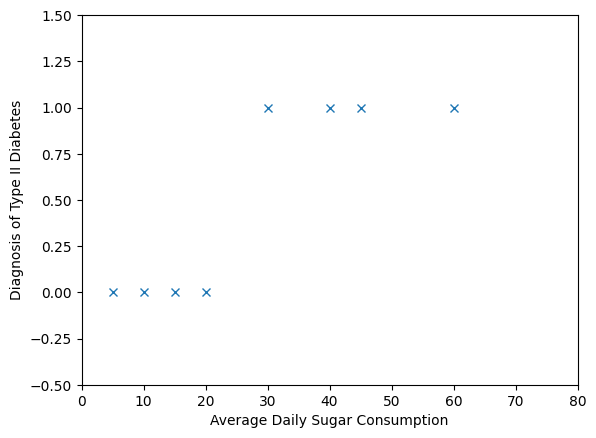

In [1]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

# Target Variable - diagnosed onset of Type II diabetes
Y = np.array([0, 0, 0, 0, 1, 1, 1, 1])

# Input Feature - Average daily consumption of added sugars in grammes
X = np.array([5, 10, 15, 20, 30, 40, 45, 60])

plt.plot(X, Y, "x")
plt.xlabel('Average Daily Sugar Consumption')
plt.ylabel('Diagnosis of Type II Diabetes')
plt.ylim([-0.5, 1.5])
plt.xlim([0, 80])
plt.show()


As can be seen, there is a clear relationship between the amount of added sugar consumed daily and the onset of Type II diabetes.

Individuals with lower average daily sugar consumption are not diagnosed with the disease, while those with higher consumption levels are diagnosed. It should be noted that this dataset is idealised and not taken from a specific real-world study.

The question, therefore, is how best to model this relationship in a way that allows us to predict the probability of a diabetes diagnosis given an individual’s average daily sugar consumption.

## Modelling Binary Targets with Linear Regression
Before introducing Logistic Regression, we first investigate the application of Linear Regression to our example.

We begin by importing two important function definitions that were previously established in the Linear Regression notes. One notable difference in our approach here is that we separate the calculation of the linear regression hypothesis into its own function. This separation makes it easier to later transition from Linear Regression to Logistic Regression, as the underlying hypothesis function can be swapped without changing the rest of the implementation.

In [2]:
# Standardization over 2D arrays
def standardize(x):
    col_means = np.mean(x,axis=0)
    col_std = np.std(x,axis=0)
    return (x - col_means) / col_std , col_means, col_std

# Linear Regression Function definition
def hLinear(theta_in,X_in):
    return np.matmul(theta_in,X_in)

# Cost function for Linear regression
def cost_linear(theta,xi,yi):
    # note - this function calculate the cost for all variations of theta. A vector is returned.
    h = np.matmul(theta,xi)
    rv = ((h - yi)**2) / 2
    return rv

# The outer cost function 'J' calculator. This iterates over our training cases.
def J(theta,x,y,f):
    s = 0
    m = len(x)
    for i in range(0,m):
        v = f(theta,x[i],y[i])
        s+= v
    return s / m

# implementation of the gradient descent algorithm
def gd(theta_in,min_delta_in,a_in,X_in,Y_in,h,maxiterations=-1,cost=cost_linear):
    m = len(Y_in) # number of training examples
    _ , n = np.shape(X_in) # number of features

    # define a list used to store the costs - these do not have to be calculated but are useful for debugging
    c = []

    # Create a theta variable which we will use to keep track of the current value of theta
    theta = theta_in

    # Create a list which we will use for storing theta results during optimization
    thetas = np.array(theta_in,ndmin=2)

    # Create a counter which is used for limiting the number of iterations used if maxiterations has been defined
    k = 0

    # Begin main search loop
    while maxiterations == -1 or k < maxiterations:
        k+=1
        # log the cost - useful for visualisation and later analysis
        c.append(J(theta_in,X_in,Y_in,cost))

        # save a copy of the parameters -- this is the set we will read from
        temp = np.copy(theta)
        # iterate over all features -- remember though that we apply changes in parallel
        for j in range(0,n):
            # making calculations for jth parameter
            s = 0
            # calculate our gradient update over all training cases
            for i in range(0,m):
                s+=  (h(temp.T,np.ravel(X_in[i,:])) - Y_in[i])  * X_in[i,j]
            theta[j] = temp[j] - a_in * (1/m) * s

        # log the changed parameters
        thetas = np.vstack((thetas,theta))

        # not lets check to see if we are still making progress -- i.e., that our cost is reducing
        # we check to make sure that at least one of our parameters is changing by a minimum threshold
        progressing = False
        for j in range(0,n):
            if(abs(temp[j] - theta[j]) > min_delta_in):
                progressing = progressing | True
        if not progressing: break

    # if we have completed a maximum number of iterations -- or if we are no longer improving -- return
    return thetas, c

We begin by first normalizing our data with z-score standardization.

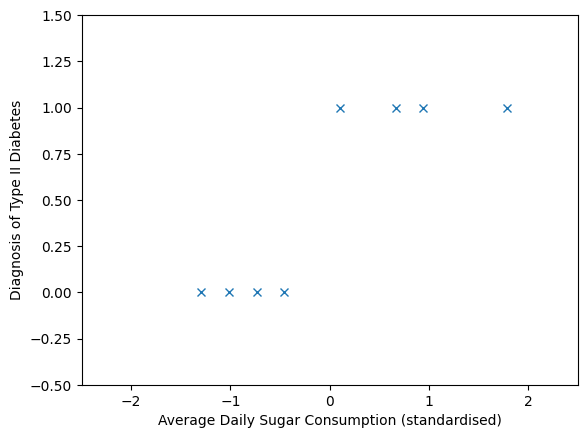

In [3]:
X, means, stds = standardize(X)

plt.plot(X,Y, "x")
plt.xlabel('Average Daily Sugar Consumption (standardised)')
plt.ylabel('Diagnosis of Type II Diabetes')
plt.ylim([-0.5,1.5])
plt.xlim([-2.5,2.5])
plt.show()

We can then directly apply Linear Regression to our training data set.   

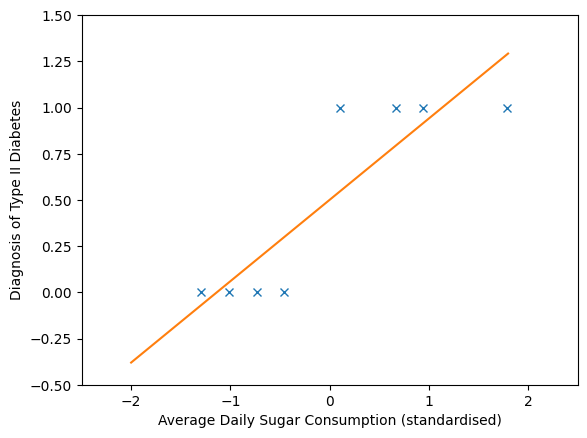

In [4]:
# define initial values for theta
theta = np.ones(2)
theta[0] = np.mean(Y) # remember - we directly calculate t0

# set min_delta and a
md = 0.01
a = 0.75

# define the new matrix X based around our standardized vector for X previously obtained
# remember that x_0 are fake features that we always set to 0 as it makes the calculations easier
x_0 = np.array([1]*len(X))
X = np.vstack((x_0,X)).T

# Run gradient descent
thetas,costs = gd(theta,md,a,X,Y,hLinear)

# plot a number of new points based on the returned function parameters
x1 = np.arange(-2,2,0.2)
x0 = np.array([1]*len(x1))
x = np.vstack((x0,x1)).T
y = np.matmul(thetas[-1,:],x.T)

plt.plot(X[:,1],Y, "x")
plt.xlabel('Average Daily Sugar Consumption (standardised)')
plt.ylabel('Diagnosis of Type II Diabetes')
plt.ylim([-0.5,1.5])
plt.xlim([-2.5,2.5])
plt.plot(x[:,1],y)
plt.show()

Looking at the output of our Linear Regression function, we are reminded that its range is $R$. As such, it is not well suited to a classification task, since the model can produce values below 0 or above 1. However, we can address this limitation by adopting a simple thresholding policy such that if:
\begin{equation}
  h_{\theta}(x) \geq 0.5 \; then \; y = 1
\end{equation}
\begin{equation}
  h_{\theta}(x) \leq 0.5 \; then \; y = 0
\end{equation}

which can be coded as follows:

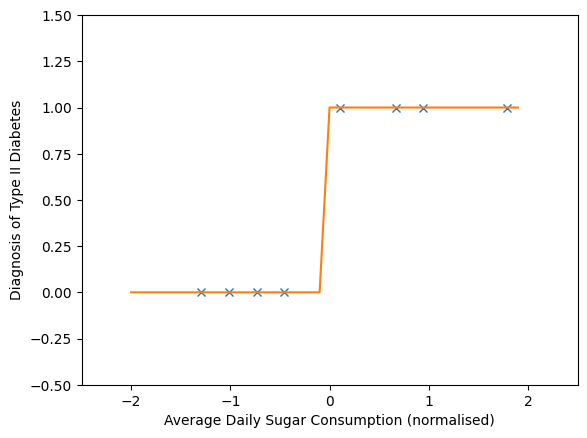

In [5]:
def threshold(x):
    if x >= 0.5: return 1
    else: return 0
threshold = np.vectorize(threshold)

# plot a number of new points based on the returned function parameters
x1 = np.arange(-2,2,0.1)
x0 = np.array([1]*len(x1))
x = np.vstack((x0,x1)).T
y = np.matmul(thetas[-1,:],x.T)
y = threshold(y)

plt.plot(X[:,1],Y, "x")
plt.xlabel('Average Daily Sugar Consumption (normalised)')
plt.ylabel('Diagnosis of Type II Diabetes')
plt.ylim([-0.5,1.5])
plt.xlim([-2.5,2.5])
plt.plot(x[:,1],y)
plt.show()

#### Problems with Linear Regression

Looking at the output of our function, it appears to provide a reasonably good approximation of the data, with all data points aligning well with the function output. However, this simple thresholded approach has two major limitations:

 * First, the thresholded function is not smooth. This is important when training models, as many optimization algorithms rely on the function being continuous and differentiable so that derivatives can be computed.

 * Linear regression is fundamentally designed to answer the question: given a value of `X`, what is the average value of `Y`? It learns the line that best fits the data by minimizing squared error, without any consideration for class separation or decision boundaries. When linear regression is applied to a classification problem—especially when classes overlap or labels are noisy—the “middle” of the data often contains examples from both classes. As a result, the model places the fitted line through this middle region, producing outputs such as 0.3, 0.5, or 0.6. These values represent averages rather than class decisions, which highlights a fundamental mismatch: linear regression aims to model the central tendency of the data, whereas classification requires learning a boundary that separates classe

 * The function performs poorly when the underlying data distributions are not as ideal or cleanly separable.

 * Linear regression tries to draw a line through the middle of the data, while classification requires drawing a boundary between classes.

To better understand these limitations, let us extend our diabetes example by introducing several additional data points.

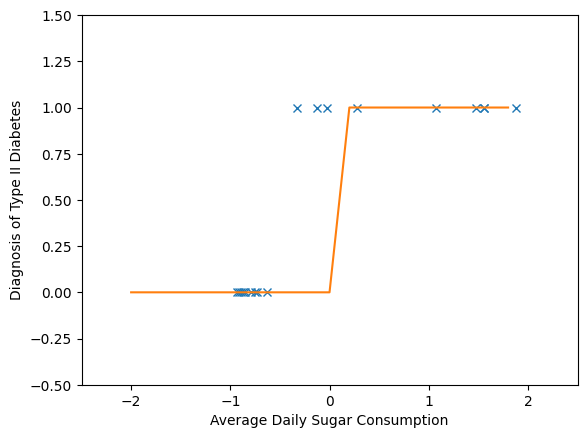

In [6]:
# define data and standardize
Y = np.array([0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1])
X = np.array([0,1,2,3,4,7,9,10,15,30,40,45,60,100,120,124,124,140])
X, means, stds = standardize(X)

# define initial values for theta
theta = np.ones(2)
theta[0] = np.mean(Y) # remember - we directly calculate t0

# set min_delta and a
md = 0.01
a = 0.75

# define the new matrix X based around our standardized vector for X previously obtained
x_0 = np.array([1]*len(X))
X = np.vstack((x_0,X)).T

# Run gradient descent
thetas,costs = gd(theta,md,a,X,Y,hLinear)

# plot a number of new points based on the returned function parameters
x1 = np.arange(-2,2,0.2)
x0 = np.array([1]*len(x1))
x = np.vstack((x0,x1)).T
y = np.matmul(thetas[-1,:],x.T)
y = threshold(y)

plt.plot(X[:,1],Y, "x")
plt.xlabel('Average Daily Sugar Consumption')
plt.ylabel('Diagnosis of Type II Diabetes')
plt.ylim([-0.5,1.5])
plt.xlim([-2.5,2.5])
plt.plot(x[:,1],y)
plt.show()

In this case, we can see that a number of instances with label 1 are now incorrectly classified as 0. This occurs despite the fact that there is still a clear boundary between cases labeled 0 and those labeled 1.

In summary, while Linear Regression can be used to address problems of this type, it is not a particularly suitable solution. As we will see, Logistic Regression provides an approach that is specifically designed for binary classification problems.

## The Logistic Function
Logistic Regression is based on the idea that a particular type of function—the logistic function—provides a more appropriate fit for binary classification data than either a straightforward linear function or a thresholded linear function. The logistic function maps real-valued inputs to the interval (0,1), making it well suited for modeling class probabilities. The logistic function is of the form:

\begin{equation}
 h_{\theta}(x) = \frac{1}{1+e^{-z}}
\end{equation}

where $z$ can be any real number, but in our case it is typically defined as $\theta^{T}X$, that is, the output of a linear function as used in Linear Regression. This value z is often called the logit.

We can gain intuition about the structure and behaviour of the logistic function by visualising its individual components.

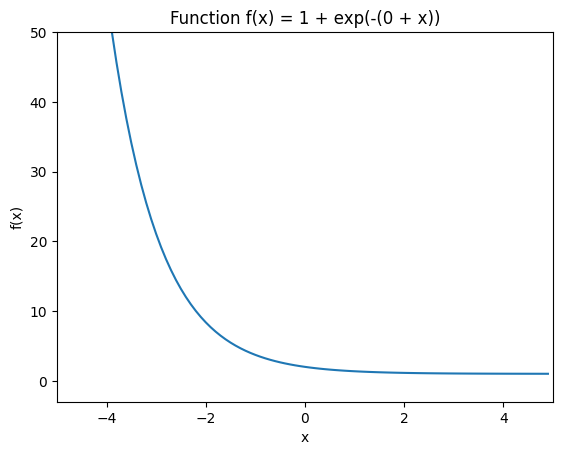

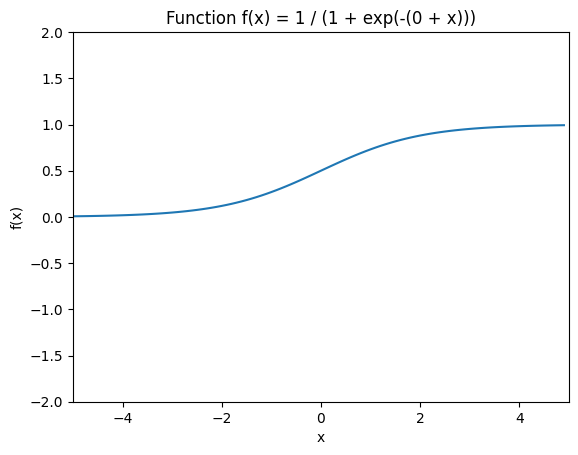

In [7]:
x1 = np.arange(-5,5,0.1)
x0 = np.array([1]*len(x1))
x = np.vstack((x0,x1))
z = np.matmul(np.array([0,1]),x)

plt.plot(x1,1+np.exp(-z))
plt.xlim([-5,5])
plt.ylim([-3,50])
plt.title('Function f(x) = 1 + exp(-(0 + x))')
plt.ylabel("f(x)")
plt.xlabel("x")
plt.show()
plt.plot(x1,1/(1 + np.exp(-z)))
plt.xlim([-5,5])
plt.ylim([-2,2])
plt.title('Function f(x) = 1 / (1 + exp(-(0 + x)))')
plt.ylabel("f(x)")
plt.xlabel("x")
plt.show()

We see that the function $f(x) = 1+e^{-x}$ is a vertically displaced inverse exponential function which has a limit of $1$ in the positive x direction and a limit of infinity in the negative x direction. Our Logistic Function is the reciprocal value of this function. Considering the limits just mentioned, the limits of the reciprocal are therefore $\frac{1}{\infty} = 0$ in the negative x direction and $\frac{1}{1} = 1$ in the positive x direction. This gives us a convenient s-shaped function that is bounded between 0 and 1.

Using the vector notation introduced for Linear Regression we can re-write the Logistic Function as follows:

\begin{equation}
 h_{\theta}(x) = g(\theta^{T}x)
\end{equation}

where

\begin{equation}
 g(z) = \frac{1}{1+e^{-z}}
\end{equation}

This is the general form of the Logistic Function that we will use throughout this section. We see that the parameter $z$ is taken to be the product of $\theta$ and $x$ as used in the linear regression equation. At this stage it is worth noting that this is a very important function in Deep Learning and is worth paying attention to.

The severity of the transition between 0 and 1 is controlled by the parameter $\theta_{1}$. We can illustrate this with a number of examples:

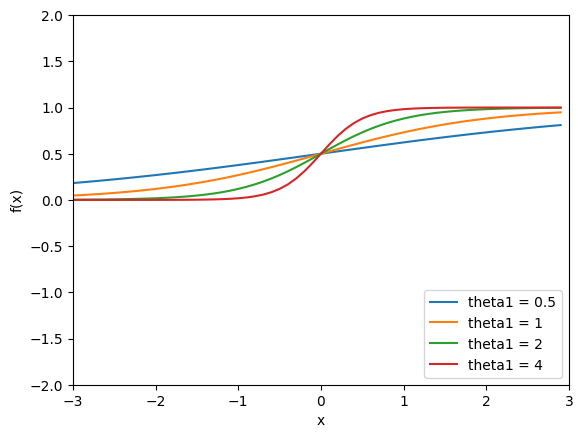

In [8]:
x1 = np.arange(-3,3,0.1)
x0 = np.array([1]*len(x1))
x = np.vstack((x0,x1))
z0 = np.matmul(np.array([0,0.5]),x)
z1 = np.matmul(np.array([0,1]),x)
z2 = np.matmul(np.array([0,2]),x)
z3 = np.matmul(np.array([0,4]),x)

plt.plot(x1,1/(1 + np.exp(-z0)))
plt.plot(x1,1/(1 + np.exp(-z1)))
plt.plot(x1,1/(1 + np.exp(-z2)))
plt.plot(x1,1/(1 + np.exp(-z3)))
plt.xlim([-3,3])
plt.ylim([-2,2])
plt.ylabel("f(x)")
plt.xlabel("x")
plt.legend(['theta1 = 0.5','theta1 = 1', 'theta1 = 2', 'theta1 = 4'], loc='lower right')
plt.show()

Similarly we can see that the logistic function is displaced along the x axis through the parameter $\theta_{0}$.

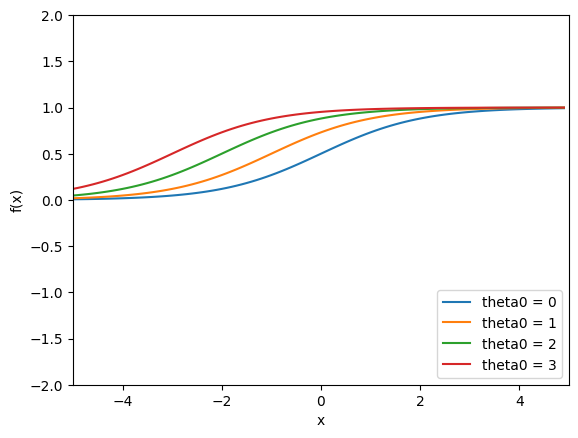

In [9]:
x1 = np.arange(-5,5,0.1)
x0 = np.array([1]*len(x1))
x = np.vstack((x0,x1))
z1 = np.matmul(np.array([0,1]),x)
z2 = np.matmul(np.array([1,1]),x)
z3 = np.matmul(np.array([2,1]),x)
z4 = np.matmul(np.array([3,1]),x)

plt.plot(x1,1/(1 + np.exp(-z1)))
plt.plot(x1,1/(1 + np.exp(-z2)))
plt.plot(x1,1/(1 + np.exp(-z3)))
plt.plot(x1,1/(1 + np.exp(-z4)))
plt.xlim([-5,5])
plt.ylim([-2,2])
plt.ylabel("f(x)")
plt.xlabel("x")
plt.legend(['theta0 = 0', 'theta0 = 1', 'theta0 = 2', 'theta0 = 3'], loc='lower right')
plt.show()

### Aside: Logistic Functions & Sigmoid Functions

The logistic function is one specific example of a broader family of functions known as sigmoid functions. Sigmoid functions are characterised by their S-shaped curves and by the fact that they smoothly transition between two limiting values.

Several commonly used sigmoid functions include:

\begin{equation}
f(x) = tanh(x)
\end{equation}

\begin{equation}
f(x) = \frac{x}{1 + |x|}
\end{equation}

These functions share the same qualitative behaviour as the logistic function: they are smooth, monotonic, and exhibit saturation at their extremes. However, their output ranges differ. For example, `tanh(x)` is bounded between `−1` and 1, whereas the logistic function is bounded between
`0`and `1`.

We illustrate these functions below alongside the logistic function. This comparison highlights that not all sigmoid functions are naturally bounded between 0 and 1, which is why the logistic function is particularly well-suited for probabilistic interpretation in binary classification.

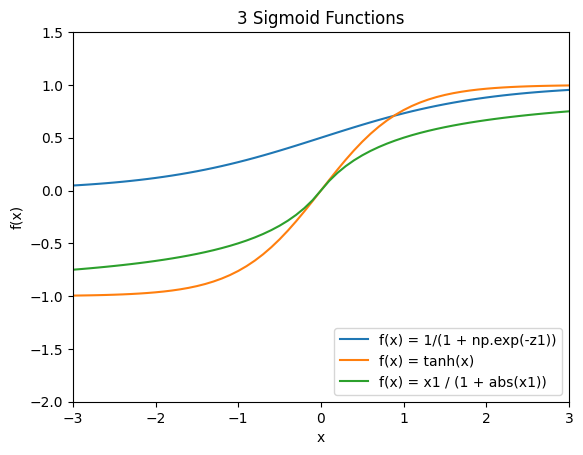

In [10]:
plt.plot(x1,1/(1 + np.exp(-z1)))
plt.plot(x1,np.tanh(x1))
plt.plot(x1,x1 / (1 + abs(x1)))

plt.xlim([-3,3])
plt.ylim([-2,1.5])
plt.ylabel("f(x)")
plt.xlabel("x")
plt.title("3 Sigmoid Functions")
plt.legend(['f(x) = 1/(1 + np.exp(-z1))', 'f(x) = tanh(x)', 'f(x) = x1 / (1 + abs(x1))'], loc='lower right')
plt.show()

### Interpreting the Logistic Function
As noted the Logistic Function gives an output in [0,1]. This helps us to give our logistic function based model $h_{\theta}$ a  probabilistic interpretation. Namely we interpret $h_{\theta}(x)$ as the estimated probability that $y=1$ given an input $x$. More formally

\begin{equation}
h_{\theta}(x) = P(Y=1 \;|\; x_{i},\theta)
\end{equation}

This gives us a good mechanism for balancing out the fact that we know $Y\in\{0,1\}$ while $h_{\theta}(x) \in [0,1]$.   From this we can also obtain:

\begin{equation}
P(Y=0 \;|\; x_{i},\theta) = 1 - h_{\theta}(x)
\end{equation}

We can also interpret our hypothesis function as defining a **Decision Boundary** between cases where we expect $Y=1$ and $Y=0$. In general we expect $Y=1$ where $h_{\theta}(x)>=0.5$ and $Y=0$ where $h_{\theta}(x)<0.5$.

### Applying Logistic Function to the Diabetes Dataset
Given our definition of the Logistic function, we can manually fit a logistic function to our Diabetes data from above.

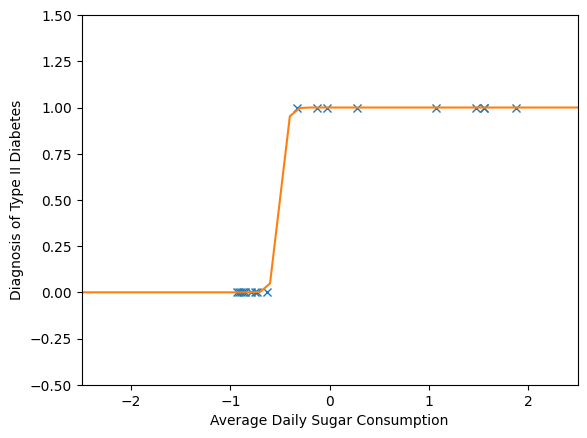

In [11]:
plt.plot(X[:,1],Y, "x")
plt.xlabel('Average Daily Sugar Consumption')
plt.ylabel('Diagnosis of Type II Diabetes')

x1 = np.arange(-2.5,3,0.1)
x0 = np.array([1]*len(x1))
x = np.vstack((x0,x1))
z1 = np.matmul(np.array([15,30]),x)

#logistic sigmoid function
plt.plot(x1,1/(1 + np.exp(-z1)))
plt.ylim([-0.5,1.5])
plt.xlim([-2.5,2.5])
plt.show()

We can see that:
- The logistic function provides a much better fit than a simple thresholded linear function.
- The transition from 0 → 1 is displaced to match where the change occurs in the data.
- The function is smooth, enabling gradient-based optimization.
- Previously, parameters were manually selected; now we need a way to learn them automatically through optimization.

## Logistic Cost Function
Optimization of the logistic function requires finding the set of parameters
$\theta$ that produces a function best matching our training data. However, we do not use the squared error cost function for this; instead, we use a cost function specifically designed for logistic regression.

Before introducing this new cost function, let us first consider the option of directly using the squared error cost function. The code below plots the sum of squared errors for a range of values of X and Y.

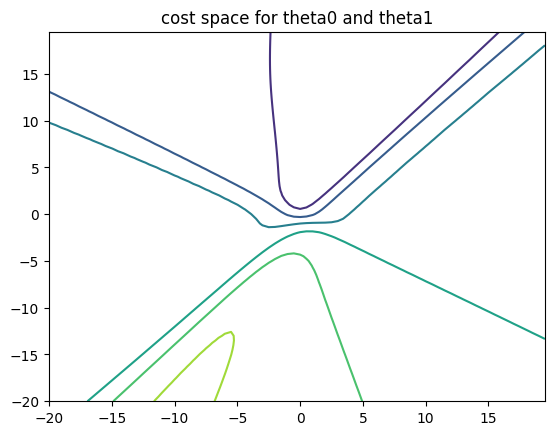

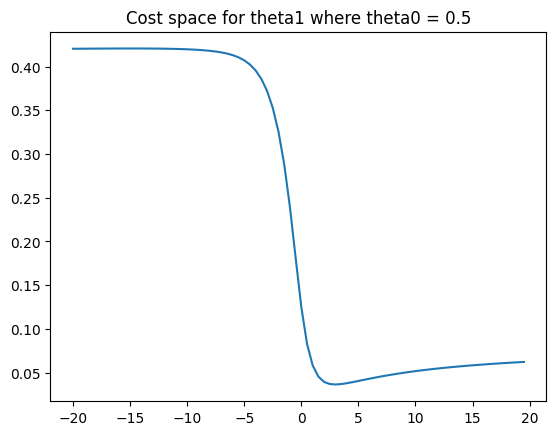

In [12]:
from matplotlib import cm

def cost(theta,xi,yi):
    # note - this function calculate the cost for all variations of theta. A vector is returned.
    z = np.matmul(theta,xi)
    h = 1 / (1 + np.exp(-z))
    rv = ((h - yi)**2) / 2
    return rv

def J(theta,x,y,f):
    s = 0
    m = len(x)
    for i in range(0,m):
        v = f(theta,x[i],y[i])
        s+= v
    return s / m

theta0_range = np.arange(-20,20,0.5)
theta1_range = np.arange(-20,20,0.5)

theta0s, theta1s = np.meshgrid(theta0_range, theta1_range)
mesh_rows, mesh_cols = theta0s.shape

theta0s_id = np.ravel(theta0s)
theta1s_id = np.ravel(theta1s)
theta = np.vstack((theta0s_id,theta1s_id)).T   # 10000 x 2 10000 different theta sets

costs = J(theta,X,Y,cost)

# reshape result to have the same organization as result of meshgrid \n",
costs = np.reshape(costs,(mesh_rows,mesh_cols))

plt.figure()
plt.contour(theta0s,theta1s,costs)
plt.title("cost space for theta0 and theta1")
plt.show()

theta1_range = np.arange(-20,20,0.5)
theta0_range = np.array([0.0]*len(theta1_range))
theta = np.vstack((theta0_range,theta1_range)).T   # 10000 x 2 10000 different theta sets
costs = J(theta,X,Y,cost)

plt.figure()
plt.plot(theta1_range,costs)
plt.title("Cost space for theta1 where theta0 = 0.5")
plt.show()

We can see that, in this case, the error surface is much more complex than in linear regression. The simple bowl-shaped convex function has been replaced by a non-convex function. While this may not pose a problem for the current example, a non-convex cost function can lead to non-optimal solutions in more complex scenarios.

### Cross Entropy Loss Function

For Logistic Regression we base our cost function on the following cost heuristic:

\begin{equation}
cost(h_{\theta}(x^{(i)}),y^{(i)}) = -y^{(i)} log(h_{\theta}(x^{(i)}))   - (1-y) log(1 - h_{\theta}(x^{(i)}))
\end{equation}

This is referred to as the cross-entropy cost function. Although it may look a bit intimidating at first, it is actually quite straightforward and almost as easy to interpret as the sum of squared errors cost function.

To begin with, there are two important observations about this cost function. First, the cost is computed differently depending on whether the target value is 0 or 1. In other words, the function consists of two distinct parts, and only one of them applies depending on the value of the label.

Second, the cost function heavily penalizes predictions where the hypothesis assigns a high probability to the incorrect class.

We can illustrate both of these properties by plotting the cost function separately for the cases y=1 and y=0.

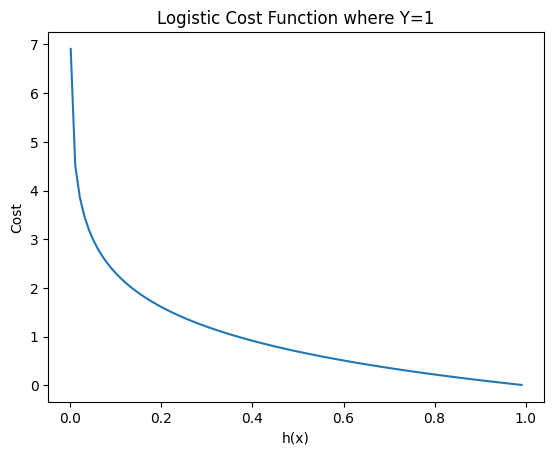

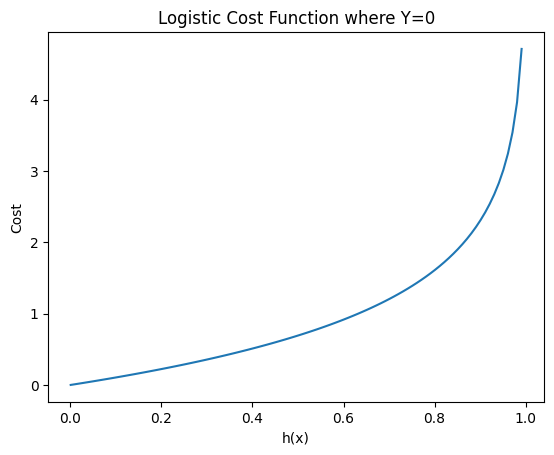

In [13]:
h = np.arange(0.001,0.999,0.01)
plt.figure()
plt.xlabel('h(x)')
plt.ylabel('Cost')
plt.plot(h,-np.log(h))
plt.title("Logistic Cost Function where Y=1")
plt.show()

plt.xlabel('h(x)')
plt.ylabel('Cost')
plt.plot(h,-np.log(1-h))
plt.title("Logistic Cost Function where Y=0")
plt.show()

An important technical point is that the logistic regression cost function involves taking the logarithm of the sigmoid output.

The sigmoid function produces values strictly between 0 and 1:

$$
0 < h_\theta(x) < 1
$$

This is important because the logarithm is undefined at 0:

$$
\log(0) = -\infty
$$

If $y = 1$ and the model predicts $h_\theta(x) = 0$, the cost becomes undefined.  
Similarly, if $y = 0$ and the model predicts $h_\theta(x) = 1$, the cost is also undefined.

For this reason, when visualizing the logistic cost function, we restrict the output of the hypothesis to a range such as:

$$
h_\theta(x) \in [0.001, 0.999]
$$

In practice, due to numerical rounding, the sigmoid may produce values extremely close to 0 or 1. To avoid numerical issues, implementations typically clip the predicted values so that the logarithm is never evaluated at 0 or 1.

### Logistic Cost Function Formal Definition
We can take our cost heuristic defined above and build it in to a full formal cost definition for $J(\theta)$ as follows.

Looking again at a formal definition of cost for multivariate Linear Regression we have

\begin{equation}
J(\theta) = \frac{1}{2m}     \sum_{i=0}^{m}  (h_{\theta}(x^{(i)}) - y^{(i)})^{2}
\end{equation}

where
 * $\theta$ is the vector of parameters of our model
 * $m$ is the number of training examples
 * $y^{i}$ is the ith target value
 * $x^{i}$ is the ith feature, and
 * $h_{\theta}$ is our model / function of $x$ that we wish to evaluate.
 * 2, or rather $\frac{1}{2}$, is a constant we introduce to allow the calculation of the derivative of J to be more straightforward.

We can generalize this cost function $J(\theta)$ by moving our derivative constant inside the summation

\begin{equation}
J(\theta) = \frac{1}{m}     \sum_{i=0}^{m} \frac{1}{2} (h_{\theta}(x^{(i)}) - y^{(i)})^{2}
\end{equation}

And then separating out the summation argument into a separate function as follows:

\begin{equation}
J(\theta) = \frac{1}{m}     \sum_{i=0}^{m} cost_{linear}(h_{\theta}(x^{(i)}),y^{(i)})
\end{equation}

where

\begin{equation}
cost_{linear}(h_{\theta}(x^{(i)}),y^{(i)})  = \frac{1}{2} (h_{\theta}(x^{(i)}) - y^{(i)})^{2}
\end{equation}

Using the general template for $J(\theta)$ we can substitute our heuristic for Logistic Regression to obtain the following function:

 \begin{equation}
J(\theta) = \frac{1}{m} \sum_{i=1}^{m} cost_{logistic}(h_{\theta}(x^{(i)}),y^{(i)})
\end{equation}

where

\begin{equation}
cost_{logistic}(h_{\theta}(x^{(i)}),y^{(i)}) = -y^{(i)} log(h_{\theta}(x^{(i)}))   - (1-y^{(i)}) log(1 - h_{\theta}(x^{(i)}))
\end{equation}

Note that our general template for $J(\theta)$ simply states that we average over individual costs for each data point. Costs for individual data points are calculated very differently between our original Linear Regression cost function and our Logistic Regression Cost Function.

We can illustrate the properties of our Logistic Cost function directly with a number of examples with respect to our Diabetes data set.

In [14]:
def cost_logistic(theta,xi,yi):
    # note - this function calculate the cost for all variations of theta. A vector is returned.
    z = np.matmul(theta,xi)
    h = 1 / (1 + np.exp(-z))
    if yi == 1:
        return -np.log(h)
    elif yi == 0:
        return -np.log(1-h)
    else: raise ValueError('yi was neither 0 nor 1: ' + str(yi))

costs = J(np.array([15.0,30.0]),X,Y,cost_logistic)
print("Costs : " + str(costs))

# shift to the left - all y=0 cases should fail
costs = J(np.array([30.0,30.0]),X,Y,cost_logistic)
print("Costs : " + str(costs))

# shift to the right - some y=1 cases should fail
costs = J(np.array([0.0,30.0]),X,Y,cost_logistic)
print("Costs : " + str(costs))

# shift to the right - some y=1 cases should fail
costs = J(np.array([1.0,1.0]),X,Y,cost_logistic)
print("Costs : " + str(costs))

# shift to the right - some y=1 cases should fail
costs = J(np.array([0.0,0.0]),X,Y,cost_logistic)
print("Costs : " + str(costs))


Costs : 0.0015778308789776117
Costs : 2.7755862143275576
Costs : 0.8243068625612893
Costs : 0.4914370094254397
Costs : 0.6931471805599453


Similarly we can plot a contour map of the logistic regression cost function over a range of parameter values.

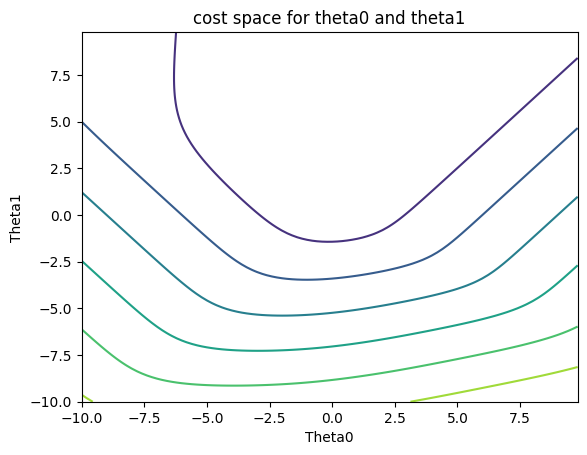

In [15]:
theta0_range = np.arange(-10,10,0.2)
theta1_range = np.arange(-10,10,0.2)

theta0s, theta1s = np.meshgrid(theta0_range, theta1_range)
mesh_rows, mesh_cols = theta0s.shape

theta0s_id = np.ravel(theta0s)
theta1s_id = np.ravel(theta1s)
theta = np.vstack((theta0s_id,theta1s_id)).T   # 10000 x 2 10000 different theta sets

costs = J(theta,X,Y,cost_logistic)

# reshape result to have the same organization as result of meshgrid \n",
costs = np.reshape(costs,(mesh_rows,mesh_cols))

plt.figure()
plt.contour(theta0s,theta1s,costs)
plt.xlabel('Theta0')
plt.ylabel('Theta1')
plt.title("cost space for theta0 and theta1")
plt.show()

We can see from the above that we once again have our conventional convex cost function with a bowl shape.

### Gradient Descent for Logistic Regression

The Gradient Descent algorithm as defined in the notes for Linear Regression was dependent on the partial derivative of the linear regression Cost Function $J(\theta)$ rather than the Cost Function itself. The same is true here for Logistic Regression. In order to implement gradient descent for Logistic Regression we must calculate the partial derivatives of the Logistic Regression Cost Function.

Fortunately the partial derivatives of the Logistic Regression Cost Function is identical to that for Linear Regression with the exception that we now use the Logistic Regression definition of our hypothesis function rather than the Linear Regression form. Specifically:

\begin{equation}
\frac{\partial}{\partial \theta_{j}}J_{logistic}(\theta) =  \frac{1}{m} \sum_{i=0}^{m} (h_{logistic,\theta}(x^{(i)}) - y^{(i)}).x^{(i)}
\end{equation}

Given this we can easily repurpose our Gradient Descent algorithm to perform search of the Logistic Function space by providing a new definition for our hypothesis function.

In [16]:
def hLogistic(theta_in,X_in):
    z = np.matmul(theta_in,X_in)
    return 1 / (1 + np.exp(-z))

We can test this new definition by applying it to our normalized training data.

Theta is : [1. 1.]
md is : 0.01
a is  : 10
t is  : [ 8.80234829 18.86899376]


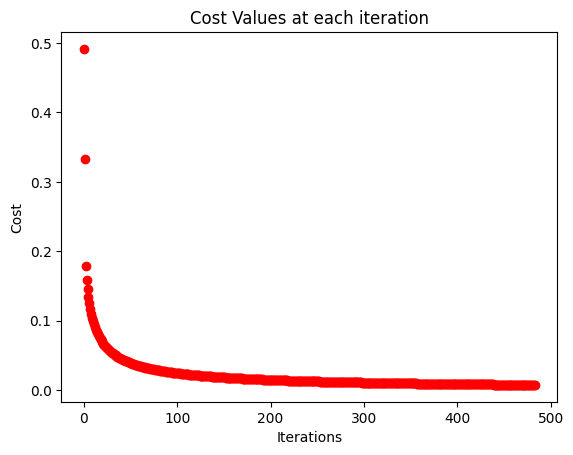

In [17]:
# define initial values for theta
rows, cols = X.shape
theta = np.array([1.0,1.0])

print("Theta is : " + str(theta))
a = 10
md = 0.01
# Run gradient descent
print("md is : " + str(md))
print("a is  : " + str(a))
thetas, c = gd(theta,md,a,X,Y,hLogistic,cost=cost_logistic)
print("t is  : " + str(thetas[-1]))

plt.plot(c, 'ro')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title("Cost Values at each iteration")
plt.show()

## Multivariate Logistic Regression
We can easily extend our method above to create a multivariate example with two features. In this case our data is idealized to show a linear decision boundary over two dimensions.

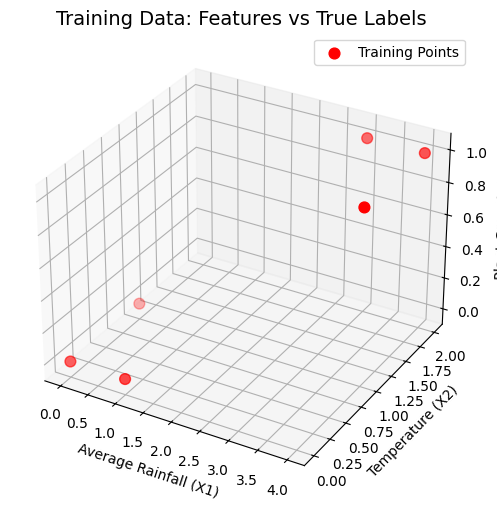

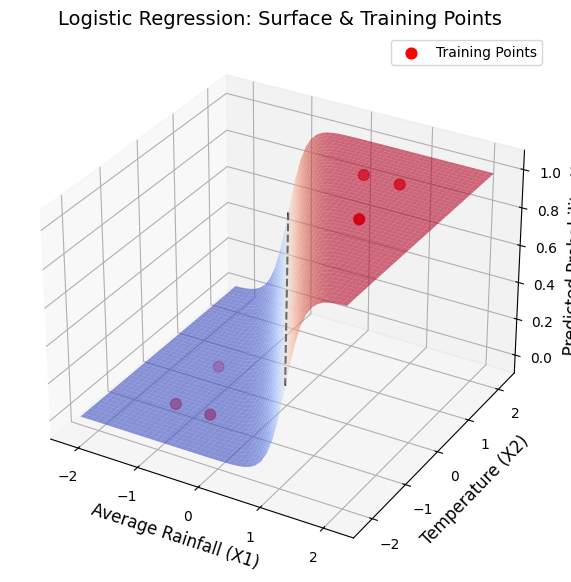

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# ---------- Helper functions ----------
def standardize(X):
    """Standardize features"""
    means = np.mean(X, axis=0)
    stds = np.std(X, axis=0)
    X_std = (X - means) / stds
    return X_std, means, stds

def hLogistic(theta, X):
    """Sigmoid / logistic function"""
    z = X @ theta
    return 1 / (1 + np.exp(-z))

def gd(theta_in, min_delta, alpha, X, Y, h, max_iter=10000):
    """Simple gradient descent for logistic regression"""
    theta = theta_in.copy()
    m = len(Y)
    thetas = [theta.copy()]

    for _ in range(max_iter):
        h_val = h(theta, X)
        gradient = (1/m) * (X.T @ (h_val - Y))
        theta -= alpha * gradient
        thetas.append(theta.copy())

        if np.all(np.abs(alpha*gradient) < min_delta):
            break
    return np.array(thetas)

# ---------- 2D Training Data ----------
Y = np.array([0,0,0,1,1,1])
X1 = np.array([0,1,0,4,3,4])
X2 = np.array([0,0,1,1,2,2])
X = np.vstack((X1, X2)).T

# ---------- 3D Plot 1: Raw training points ----------
fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.add_subplot(111, projection='3d')
ax1.scatter(X1, X2, Y, color='red', s=60, label='Training Points')
ax1.set_xlabel('Average Rainfall (X1)')
ax1.set_ylabel('Temperature (X2)')
ax1.set_zlabel('Plant Growth / Y')
ax1.set_title('Training Data: Features vs True Labels', fontsize=14)
ax1.set_zlim(-0.1, 1.1)
ax1.legend()
plt.show()

# ---------- Standardize features for logistic regression ----------
X_std, means, stds = standardize(X)

# Add bias term
rows, cols = X_std.shape
X_bias = np.hstack((np.ones((rows,1)), X_std))

# ---------- Gradient descent ----------
theta_init = np.ones(cols+1)
md = 1e-4  # minimum delta
alpha = 0.5  # learning rate
thetas = gd(theta_init, md, alpha, X_bias, Y, hLogistic)

# Final theta
theta_final = thetas[-1,:]

# ---------- Create meshgrid for surface ----------
x_range = np.linspace(X_std[:,0].min()-1, X_std[:,0].max()+1, 50)
y_range = np.linspace(X_std[:,1].min()-1, X_std[:,1].max()+1, 50)
x1s, x2s = np.meshgrid(x_range, y_range)

# Flatten and add bias for computation
x1_flat = x1s.ravel()
x2_flat = x2s.ravel()
x0_flat = np.ones_like(x1_flat)
X_mesh = np.vstack((x0_flat, x1_flat, x2_flat)).T

# Compute predictions
z = hLogistic(theta_final, X_mesh)
zs = z.reshape(x1s.shape)

# ---------- 3D Plot 2: Logistic regression surface + points ----------
fig2 = plt.figure(figsize=(10,7))
ax2 = fig2.add_subplot(111, projection='3d')

# Surface = predicted probability
surf = ax2.plot_surface(x1s, x2s, zs, rstride=1, cstride=1, cmap=cm.coolwarm, alpha=0.6)

# Scatter = actual points
ax2.scatter(X_std[:,0], X_std[:,1], Y, color='red', s=60, label='Training Points')

# Contour for decision boundary at probability = 0.5
ax2.contour(x1s, x2s, zs, levels=[0.5], colors='black', linestyles='--', offset=0.5)

# Axis labels
ax2.set_xlabel('Average Rainfall (X1)', fontsize=12)
ax2.set_ylabel('Temperature (X2)', fontsize=12)
ax2.set_zlabel('Predicted Probability / Y', fontsize=12)

# Limits and title
ax2.set_zlim(-0.1, 1.1)
ax2.set_title('Logistic Regression: Surface & Training Points', fontsize=14)
ax2.legend()
plt.show()


## Non-Linear Logistic Regression
As with Linear Regression, we can extend Logistic Regression to produce non-linear decision boundaries by introducing additional non-linear functions of the input features.

For example, consider a case where the positive examples are clustered at the center, while the negative examples form a ring around that cluster, as illustrated below. In such a scenario, a simple linear decision boundary is insufficient, but Logistic Regression can still model the problem effectively by operating on suitably transformed features.

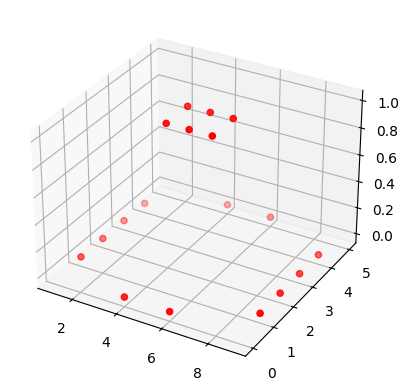

In [19]:
# Define the training data
Y = np.array([ 0,0,0,0,0,       1,1,1,  0,0,    1,1,1,     0,0,0,0,0])
X1 = np.array([4,6,1,9,1,       4,5,6,  9,1,    4,5,6,     9,1,9,4,6])
X2 = np.array([0,0,1,1,2,       2,2,2,  2,3,    3,3,3,     3,4,4,5,5])
X = np.vstack((X1,X2)).T

# Plot the training data in our usual way where the Target variable occupies the z-axis
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X1, X2, Y, c='r', marker='o')
plt.show()

Or with normalized data:

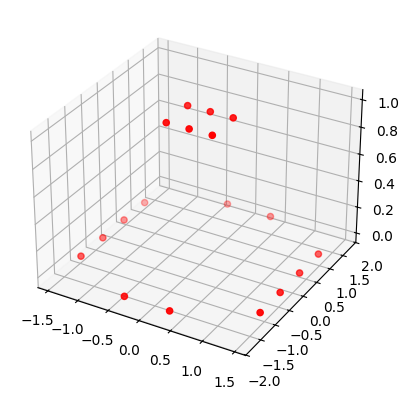

In [20]:
# standardize our input features
X, means, stds = standardize(X)

# Plot the training data in our usual way where the Target variable occupies the z-axis
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], Y, c='r', marker='o')
plt.show()

If we try to model this data distribution directly, the resulting fit is poor. Without restricting the number of iterations, gradient descent does not converge to a meaningful solution and instead oscillates around the parameter space, failing to settle on a stable decision boundary.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


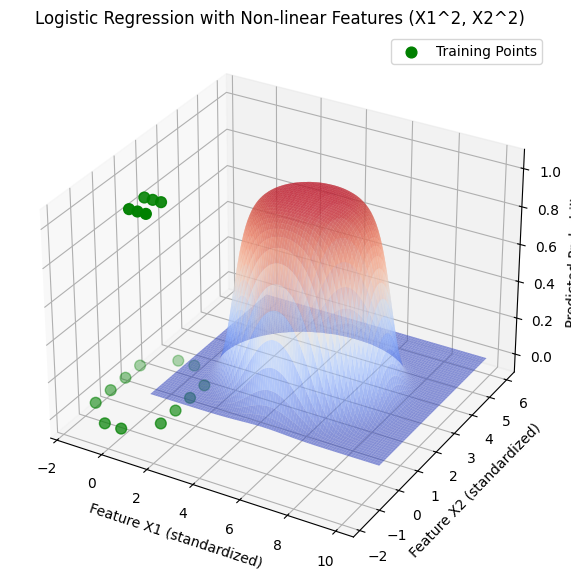

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# ---------- Helper Functions ----------
def standardize(X):
    """Standardize features"""
    means = np.mean(X, axis=0)
    stds = np.std(X, axis=0)
    X_std = (X - means) / stds
    return X_std, means, stds

def hLogistic(theta, X):
    """Sigmoid / logistic function"""
    z = X @ theta
    return 1 / (1 + np.exp(-z))

def gd(theta_in, min_delta, alpha, X, Y, h, max_iter=10000):
    """Simple gradient descent for logistic regression"""
    theta = theta_in.copy()
    m = len(Y)
    thetas = [theta.copy()]

    for _ in range(max_iter):
        h_val = h(theta, X)
        gradient = (1/m) * (X.T @ (h_val - Y))
        theta -= alpha * gradient
        thetas.append(theta.copy())
        if np.all(np.abs(alpha * gradient) < min_delta):
            break
    return np.array(thetas)

# ---------- Define Training Data ----------
Y = np.array([0,0,0,0,0, 1,1,1, 0,0, 1,1,1, 0,0,0,0,0])
X1 = np.array([4,6,1,9,1, 4,5,6, 9,1, 4,5,6, 9,1,9,4,6])
X2 = np.array([0,0,1,1,2, 2,2,2, 2,3, 3,3,3, 3,4,4,5,5])

# Engineer non-linear features
X3 = X1**2
X4 = X2**2
X = np.vstack((X1, X2, X3, X4)).T

# Standardize features
X_std, means, stds = standardize(X)

# Add bias term
rows, cols = X_std.shape
X_bias = np.hstack((np.ones((rows,1)), X_std))

# ---------- Gradient Descent ----------
theta_init = np.ones(cols + 1)
md = 1e-4
alpha = 5
thetas = gd(theta_init, md, alpha, X_bias, Y, hLogistic, max_iter=1000)

# Final theta
theta_final = thetas[-1, :]

# ---------- Create Grid for Surface ----------
x_range = np.arange(0, 10, 0.1)
y_range = np.arange(0, 6, 0.1)
x1s, x2s = np.meshgrid(x_range, y_range)

# Flatten grid and compute squared features
x1_flat = x1s.ravel()
x2_flat = x2s.ravel()
x3_flat = x1_flat**2
x4_flat = x2_flat**2

X_grid = np.vstack((x1_flat, x2_flat, x3_flat, x4_flat)).T

# Standardize grid using training means/stds
X_grid = (X_grid - means)/stds

# Add bias term
X_grid = np.hstack((np.ones((X_grid.shape[0],1)), X_grid))

# ---------- Compute Predictions ----------
z = hLogistic(theta_final, X_grid)
zs = z.reshape(x1s.shape)

# ---------- Plot 3D Surface with Training Points ----------
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(projection='3d')

# Logistic regression probability surface
surf = ax.plot_surface(x1s, x2s, zs, rstride=1, cstride=1, cmap=cm.coolwarm, alpha=0.6)

# Overlay training points
ax.scatter(X_std[:,0], X_std[:,1], Y, color='green', s=60, label='Training Points')

# Axis labels
ax.set_xlabel('Feature X1 (standardized)')
ax.set_ylabel('Feature X2 (standardized)')
ax.set_zlabel('Predicted Probability')
ax.set_zlim(-0.1, 1.1)
ax.set_title('Logistic Regression with Non-linear Features (X1^2, X2^2)')
ax.legend()
plt.show()


When viewed in 3D, the logistic regression surface may give the impression of a separation between classes. However, in practice, this is not what is happening. The plane returned essentially predicts roughly 50% probability across most locations.

What we really want is a function that closely matches the data: predicting 1 for positive cases and 0 for negative cases.

For data with a circular pattern, a circular decision boundary works better. Such a boundary can be expressed as:

\begin{equation}
X^{2} + Y^{2} + aX + bY +c = 0
\end{equation}

We can implement this by introducing two additional features: the squares of the original X and Y values as above.

Rather than using up an axis dimension to explicitly visualize the Target variable as in the case above we can instead collapse this dimension and instead represent different classes with different icons. For example we can re-visualize our results below in 2D by plotting the points and the decision space as a contour plot.

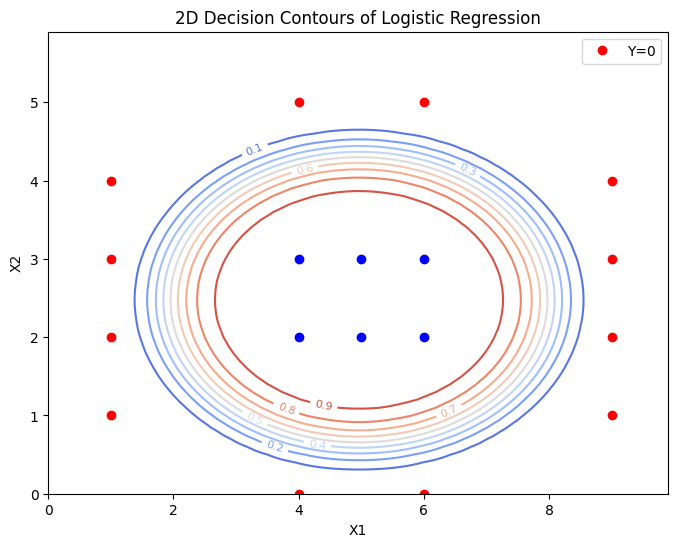

In [22]:

# ---------- 2D Contour Plot with Multiple Levels ----------
plt.figure(figsize=(8,6))

# Plot training points
for i in range(len(Y)):
    if Y[i] == 0:
        plt.plot(X[i,0], X[i,1], 'o', color='red', label='Y=0' if i==0 else "")
    else:
        plt.plot(X[i,0], X[i,1], 'o', color='blue', label='Y=1' if i==0 else "")

# Plot multiple probability contours
levels = np.linspace(0, 1, 11)  # 0.0, 0.1, 0.2, ..., 1.0
contour = plt.contour(x1s, x2s, zs, levels=levels, cmap=cm.coolwarm)
plt.clabel(contour, inline=True, fontsize=8, fmt="%.1f")  # label each contour

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('2D Decision Contours of Logistic Regression')
plt.legend()
plt.show()


## Multinomial Logistic Regression
In the example to this point our Target Variable has been a single binary variable. In many practical examples we will instead have a target variable that is multinomial, e.g., 3 different colours, or 4 different disease types.

Logistic Regression cannot directly cope with more than two class types. However we can easily adopt our usage of Logistic Regression to handle more than two classes by applying **one hot encoding** to the target variable. **One Hot Encoding** is the rewriting of a single variable with greater than 2 classes into a number of individual binary variables where each binary variable indicates the presence of one of the original 3 classes.

To illustrate consider the multinomial target Y defined as a Python list alongside the two input features X1 and X2.

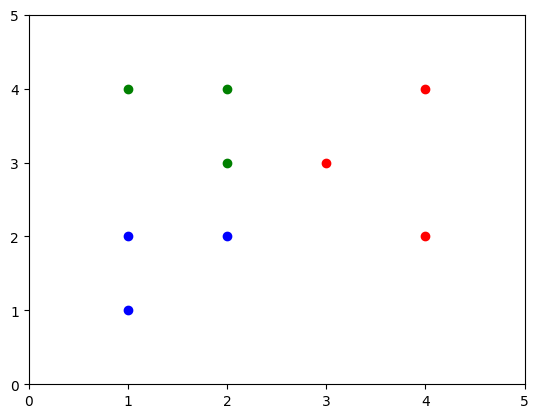

In [23]:
# Define the data - r for red, g for green, and b for blue
Y = ['b','b','r','b','g','r','g','r','g']
X1 = [1,1,4,2,2,3,1,4,2]
X2 = [1,2,4,2,3,3,4,2,4]

# Visualize as a multinomial problem
for i in range(len(Y)):
    plt.plot(X1[i],X2[i],'o',c=Y[i])
plt.ylim([0,5])
plt.xlim([0,5])
plt.show()

To recode this case we create 3 new target binary variables $Yr$, $Yg$, and $Yb$, where each variable captures where $Y$ was $r$, $g$, or $b$ respectively.

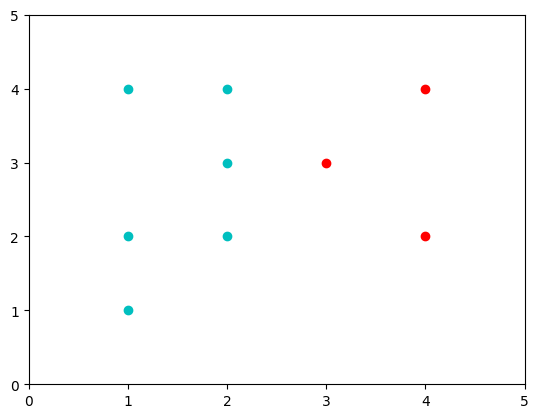

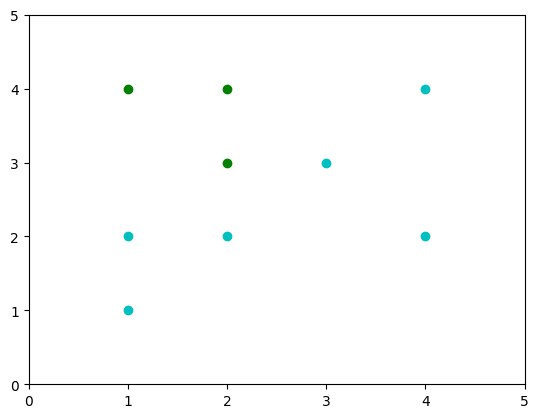

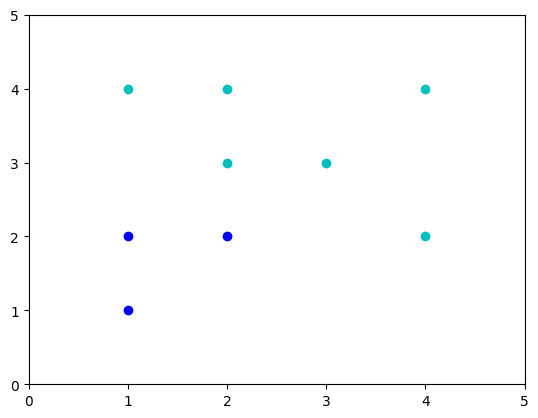

In [24]:
Yr = [1 if a =='r' else 0 for a in Y]
Yg = [1 if a =='g' else 0 for a in Y]
Yb = [1 if a =='b' else 0 for a in Y]

# Visualize as a 3 binary problem
for i in range(len(Yr)):
    if(Yr[i] == 1):
        plt.plot(X1[i],X2[i],'o',c='r')
    else:
        plt.plot(X1[i],X2[i],'o',c='c')
plt.ylim([0,5])
plt.xlim([0,5])
plt.show()

for i in range(len(Yg)):
    if(Yg[i] == 1):
        plt.plot(X1[i],X2[i],'o',c='g')
    else:
        plt.plot(X1[i],X2[i],'o',c='c')
plt.ylim([0,5])
plt.xlim([0,5])
plt.show()

for i in range(len(Yb)):
    if(Yb[i] == 1):
        plt.plot(X1[i],X2[i],'o',c='b')
    else:
        plt.plot(X1[i],X2[i],'o',c='c')
plt.ylim([0,5])
plt.xlim([0,5])
plt.show()

Rather than training one single model we end up training n distinct models - one for each of our new target variables. For a given model $i$ we are computing:

\begin{equation}
h_{\theta}^{(i)} (x) = P(y=i \;|\ x,\theta)
\end{equation}

i.e., the interpreted likelihood of the data $x$ resulting in the activation of the model with the specific parameters $\theta$. For a new data point we then simply want to produce the hypothesis for each trained model and select the maximum of these models:

\begin{equation}
\max_i h_{\theta}^{(i)}
\end{equation}


In [25]:
import numpy as np

# ---------- Example data ----------
# Input features
X1 = np.array([1,2,3,4,5])
X2 = np.array([2,3,4,5,6])
X = np.vstack((X1, X2)).T  # shape: (n_samples, n_features)

# Target variables (one-hot for 3 classes)
Yr = np.array([1,0,0,0,0])  # Red
Yg = np.array([0,1,0,0,0])  # Green
Yb = np.array([0,0,1,0,0])  # Blue

# ---------- Standardization ----------
def standardize(X):
    means = np.mean(X, axis=0)
    stds = np.std(X, axis=0)
    X_std = (X - means) / stds
    return X_std, means, stds

X_std, means, stds = standardize(X)

# Add bias term
rows, cols = X_std.shape
X_std = np.hstack((np.ones((rows, 1)), X_std))  # shape: (n_samples, n_features+1)

# ---------- Logistic function ----------
def hLogistic(theta, X):
    z = X @ theta
    return 1 / (1 + np.exp(-z))

# ---------- Gradient Descent ----------
def gd(theta_in, min_delta, alpha, X, Y, h, max_iter=10000):
    theta = theta_in.copy()
    m = len(Y)
    thetas = [theta.copy()]
    for _ in range(max_iter):
        h_val = h(theta, X)
        gradient = (1/m) * (X.T @ (h_val - Y))
        theta -= alpha * gradient
        thetas.append(theta.copy())
        if np.all(np.abs(alpha*gradient) < min_delta):
            break
    return np.array(thetas)

# ---------- Initialize theta ----------
theta_init = np.ones(cols+1)
md = 1e-4
alpha = 5

# Train one-vs-rest classifiers
thetas_r = gd(theta_init, md, alpha, X_std, Yr, hLogistic, max_iter=1000)
thetas_g = gd(theta_init, md, alpha, X_std, Yg, hLogistic, max_iter=1000)
thetas_b = gd(theta_init, md, alpha, X_std, Yb, hLogistic, max_iter=1000)

# ---------- Predict for new points ----------
x_new = np.array([[0, 4], [0, 3]])  # shape: (2,2)

# Standardize using training mean/std
x_new_std = (x_new - means)/stds
x_new_std = np.hstack((np.ones((x_new_std.shape[0], 1)), x_new_std))  # add bias

# Compute probabilities for each class
z_r = hLogistic(thetas_r[-1,:], x_new_std)
z_g = hLogistic(thetas_g[-1,:], x_new_std)
z_b = hLogistic(thetas_b[-1,:], x_new_std)

print("Red probabilities:", z_r)
print("Green probabilities:", z_g)
print("Blue probabilities:", z_b)

# Predicted class: class with max probability
pred_classes = np.argmax(np.vstack((z_r, z_g, z_b)), axis=0)
print("Predicted class indices (0=Red,1=Green,2=Blue):", pred_classes)


Red probabilities: [0.55886111 0.99500243]
Green probabilities: [0.35612323 0.44344443]
Blue probabilities: [0.20000987 0.20001317]
Predicted class indices (0=Red,1=Green,2=Blue): [0 0]


Therefore we can see that for multinomial logistic regression we need to train n different models for n different target labels. We will take a different approach in neural networks where we will train one single model with shared weights even in the case of a multinomial target.

## Logistic Regression the Easy Way
We can use scipy to perform Logistic Regression using the standard model interface.

In [26]:
from sklearn import linear_model
import numpy as np

# Example data
X = np.array([[0, 1], [1, 1], [2, 0], [3, 1]])
Y = np.array([0, 0, 1, 1])

# Create the Logistic Regression model
logreg = linear_model.LogisticRegression(C=1e5, solver='liblinear')

# Fit the model
model = logreg.fit(X, Y)

print(model)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


LogisticRegression(C=100000.0, solver='liblinear')
Coefficients: [[  9.00932123 -10.34735769]]
Intercept: [-7.28354602]


See SKLearn Logistic Regression 3-class Classifier for more detailed example.

## Lab Work

* Design your own classification task with a clear binary distinction based on two input variables. You will need to use the multivariate version of the code to work through this model.
* Try to construct a dataset that exhibits a clear underlying pattern, but still presents the training algorithm with a greater challenge when learning a clean classification boundary.
